In [11]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt

from utils.file_utils import get_cleaned_tickets_as_df
from utils.text_utils import get_pos_tags, lemmmatize_text, clean_text, clean_stop_words

In [12]:
tickets_df = get_cleaned_tickets_as_df()
tickets_df.head()

,ticket_number,ticket_subject,sent_by,ticket_created_on,message_created_on,message,tags
0,21,NaN,Customer,2022-01-24 14:19:01.51779,2022-01-24 14:19:01.51779,Hi! What is your pricing? Can I talk with some...,Sales
1,21,NaN,Agent,2022-01-24 14:19:01.51779,2022-01-24 14:19:27.936193,"Hi! Yes, we'd love to hop on a phone call! Whe...",Sales
2,22,NaN,Customer,2022-01-24 17:52:10.798997,2022-01-24 17:52:10.798997,"Hi, how much is Atlas?",Sales
3,22,NaN,Agent,2022-01-24 17:52:10.798997,2022-01-24 17:53:03.397358,"Looks like it, yeah.",Sales
4,30,NaN,Customer,2022-01-28 14:53:47.113617,2022-01-28 14:53:47.113617,hey not super urgent but fyi in ramp bank you ...,Feature Request


In [13]:
tickets_df["message_cleaned"] = tickets_df.message.apply(clean_text)
tickets_df["message_lemmatized"] = tickets_df.message_cleaned.apply(lemmmatize_text)
tickets_df["message_pos"] = tickets_df.message_lemmatized.apply(get_pos_tags)
tickets_df["message_stop"] = tickets_df.message_pos.apply(clean_stop_words)
tickets_df

,ticket_number,ticket_subject,sent_by,ticket_created_on,message_created_on,message,tags,message_cleaned,message_lemmatized,message_pos,message_stop
0,21,NaN,Customer,2022-01-24 14:19:01.51779,2022-01-24 14:19:01.51779,Hi! What is your pricing? Can I talk with some...,Sales,hi what is your pricing can i talk with someone,hi what be your pricing can I talk with someone,pricing someone,pricing
1,21,NaN,Agent,2022-01-24 14:19:01.51779,2022-01-24 14:19:27.936193,"Hi! Yes, we'd love to hop on a phone call! Whe...",Sales,hi yes wed love to hop on a phone call when ar...,hi yes we d love to hop on a phone call when b...,phone call,phone
2,22,NaN,Customer,2022-01-24 17:52:10.798997,2022-01-24 17:52:10.798997,"Hi, how much is Atlas?",Sales,hi how much is atlas,hi how much be atlas,atlas,atlas
3,22,NaN,Agent,2022-01-24 17:52:10.798997,2022-01-24 17:53:03.397358,"Looks like it, yeah.",Sales,looks like it yeah,look like it yeah,look,look
4,30,NaN,Customer,2022-01-28 14:53:47.113617,2022-01-28 14:53:47.113617,hey not super urgent but fyi in ramp bank you ...,Feature Request,hey not super urgent but fyi in ramp bank you ...,hey not super urgent but fyi in ramp bank you ...,hey urgent fyi bank merriam webster,hey urgent fyi bank merriam webster
...,...,...,...,...,...,...,...,...,...,...,...
5034,1528,Atlas running super slow,Customer,2024-05-13 15:55:00.357652,2024-05-13 15:55:00.909629,"Team, it's really slow today, impacting our re...",Bug,team its really slow today impacting our respo...,team its really slow today impact our response...,team today response time customer please atten...,team today response time customer attention
5035,1528,Atlas running super slow,Agent,2024-05-13 15:55:00.357652,2024-05-13 15:55:11.490352,@Carlos Antonio Garcia Leandro Junior I am che...,Bug,carlos antonio garcia leandro junior i am chec...,carlos antonio garcia leandro junior I be chec...,carlos antonio garcia leandro junior,carlos antonio garcia leandro junior
5036,1528,Atlas running super slow,Agent,2024-05-13 15:55:00.357652,2024-05-13 15:58:54.852555,@Carlos Antonio Garcia Leandro Junior it this ...,Bug,carlos antonio garcia leandro junior it this a...,carlos antonio garcia leandro junior it this a...,carlos antonio garcia leandro junior pagecusto...,carlos antonio garcia leandro junior pagecusto...
5037,1528,Atlas running super slow,Customer,2024-05-13 15:55:00.357652,2024-05-13 16:01:09.731746,Any ticket I click to open exhibits this behav...,Bug,any ticket i click to open exhibits this behav...,any ticket I click to open exhibit this behavi...,ticket exhibit behavior time page,ticket exhibit behavior time page


In [14]:
# frequency of tags

from collections import Counter

grouped_tags_df = (
    tickets_df.groupby("tags")["message_lemmatized"].apply(" ".join).reset_index()
)

# Step 2: Split Text and Count Frequencies
word_counts = {}
for idx, row in grouped_tags_df.iterrows():
    category = row["tags"]
    text = row["message_lemmatized"]
    words = text.split()
    word_counts[category] = dict(Counter(words))

# Print the results
for category, counts in word_counts.items():
    print(f"Category: {category}")
    for word, count in counts.items():
        print(f"{word}: {count}")

Category: Bug
little: 7
feedback: 8
here: 107
as: 135
I: 624
be: 1190
test: 25
the: 1264
identification: 1
set: 27
up: 56
think: 39
it: 454
only: 37
pick: 4
i: 19
d: 30
because: 28
do: 292
not: 405
see: 145
name: 28
or: 101
email: 216
in: 351
this: 548
box: 17
now: 150
at: 68
top: 11
of: 231
whole: 2
section: 2
no: 39
anywhere: 3
though: 13
adam: 16
we: 493
display: 8
that: 373
but: 188
should: 136
there: 103
side: 20
pane: 3
something: 35
like: 75
yah: 2
ya: 3
just: 101
notice: 19
datum: 28
can: 295
you: 637
send: 128
how: 59
make: 65
identify: 16
call: 59
attribute: 2
payload: 4
windowatlasidentifypayload: 1
its: 71
possible: 20
first: 28
time: 51
pass: 7
undefined: 1
for: 338
have: 339
with: 160
dev: 5
reliably: 1
find: 48
issue: 186
field: 25
getting: 8
update: 75
once: 30
user: 74
already: 21
create: 85
atlas: 117
emailname: 1
let: 104
fix: 194
tonight: 13
if: 225
try: 116
a: 628
new: 82
work: 99
ok: 12
confirm: 19
on: 294
thank: 171
check: 107
and: 440
report: 33
please: 114
keep

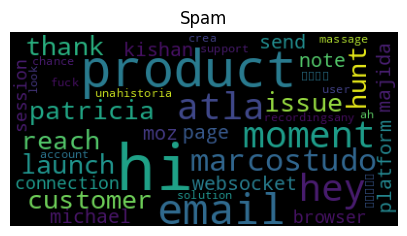

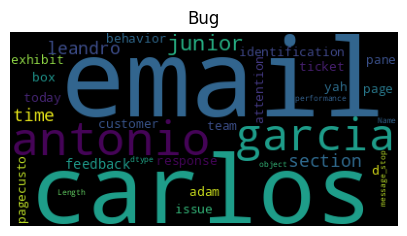

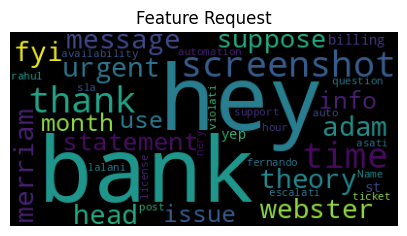

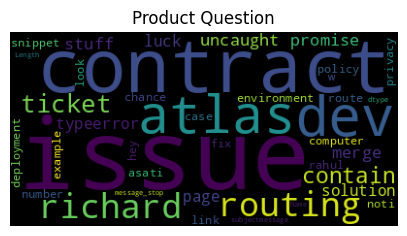

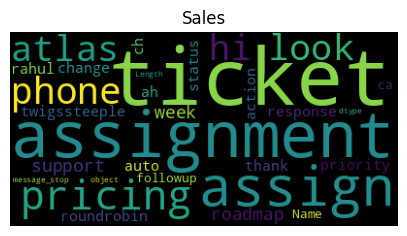

In [15]:
spam = str(tickets_df[tickets_df["tags"] == "Spam"].message_stop)

word_cloud = WordCloud(max_words=40).generate(spam)
plt.figure(figsize=(5, 3))
plt.imshow(word_cloud)
plt.axis("off")
plt.title("Spam")
plt.show()


category = str(tickets_df[tickets_df["tags"] == "Bug"].message_stop)

word_cloud = WordCloud(max_words=40).generate(category)
plt.figure(figsize=(5, 3))
plt.imshow(word_cloud)
plt.axis("off")
plt.title("Bug")
plt.show()


category = str(tickets_df[tickets_df["tags"] == "Feature Request"].message_stop)

word_cloud = WordCloud(max_words=40).generate(category)
plt.figure(figsize=(5, 3))
plt.imshow(word_cloud)
plt.axis("off")
plt.title("Feature Request")
plt.show()


category = str(tickets_df[tickets_df["tags"] == "Product Question"].message_stop)

word_cloud = WordCloud(max_words=40).generate(category)
plt.figure(figsize=(5, 3))
plt.imshow(word_cloud)
plt.axis("off")
plt.title("Product Question")
plt.show()


category = str(tickets_df[tickets_df["tags"] == "Sales"].message_stop)

word_cloud = WordCloud(max_words=40).generate(category)
plt.figure(figsize=(5, 3))
plt.imshow(word_cloud)
plt.axis("off")
plt.title("Sales")
plt.show()